# Modified TPGMM for Gait Data with Transformed Reference Frame

In [32]:
import sys
import os

import json
import numpy as np
import matplotlib.pyplot as plt

In [33]:
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

print(parent_dir)
print(os.getcwd())

/home/jemajuinta/ws/Gait-analysis-coupled/TaskPaGMMM
/home/jemajuinta/ws/Gait-analysis-coupled/TaskPaGMMM/examples


In [34]:
from tpgmm.tpgmm.tpgmm import TPGMM
from tpgmm.gmr.gmr import GaussianMixtureRegression
from tpgmm.utils.plot.plot import plot_trajectories, plot_ellipsoids, scatter
from tpgmm.utils.plot.plot import plot_trajectories_2d, plot_ellipsoids_2d

In [35]:
with open("7days1/gait_analysis_export_subject35v2.json", "r") as f:
    data = json.load(f)

# Data loading completed above - this cell is now obsolete

Trajectories manipulation

In [36]:
# Create separate lists for trajectories from each frame of reference
trajectories_fr1 = []
trajectories_fr2 = []

# Access kinematics data for FR1 and FR2
fr1_data = data['kinematics_data']['FR1']['right_leg_kinematics']
fr2_data = data['kinematics_data']['FR2']['right_leg_kinematics']

for demo_fr1, demo_fr2 in zip(fr1_data, fr2_data):
    # For FR1: right ankle position, velocity, and angle data with time
    pos_fr1 = np.array(demo_fr1['right_ankle_pos']).T  # Shape: (200, 2)
    vel_fr1 = np.array(demo_fr1['right_ankle_vel']).T  # Shape: (200, 2)
    ankle_right_deg_fr1 = np.array(demo_fr1['ankle_right_deg']).reshape(-1, 1)  # Shape: (200, 1)
    ankle_left_deg_fr1 = np.array(demo_fr1['ankle_left_deg']).reshape(-1, 1)   # Shape: (200, 1)
    
    # Create time vector for this demonstration
    num_steps = pos_fr1.shape[0]
    time_demo = np.linspace(0, 1, num_steps).reshape(-1, 1)
    
    # Stack features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
    traj1 = np.hstack([pos_fr1, vel_fr1, ankle_right_deg_fr1, ankle_left_deg_fr1, time_demo])
    trajectories_fr1.append(traj1)
    
    # For FR2: right ankle position, velocity, and angle data with time
    pos_fr2 = np.array(demo_fr2['right_ankle_pos']).T  # Shape: (200, 2)
    vel_fr2 = np.array(demo_fr2['right_ankle_vel']).T  # Shape: (200, 2)
    ankle_right_deg_fr2 = np.array(demo_fr2['ankle_right_deg']).reshape(-1, 1)  # Shape: (200, 1)
    ankle_left_deg_fr2 = np.array(demo_fr2['ankle_left_deg']).reshape(-1, 1)   # Shape: (200, 1)
    
    # Stack features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
    traj2 = np.hstack([pos_fr2, vel_fr2, ankle_right_deg_fr2, ankle_left_deg_fr2, time_demo])
    trajectories_fr2.append(traj2)

# Convert lists to numpy arrays
trajectories_fr1 = np.array(trajectories_fr1)
trajectories_fr2 = np.array(trajectories_fr2)

print(f"Trajectories FR1 shape: {trajectories_fr1.shape}")
print(f"Trajectories FR2 shape: {trajectories_fr2.shape}")
print(f"Number of demonstrations: {len(trajectories_fr1)}")
print(f"Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")

Trajectories FR1 shape: (11, 200, 7)
Trajectories FR2 shape: (11, 200, 7)
Number of demonstrations: 11
Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]


In [37]:
# Apply +18 degree rotation to all FR2 trajectories using homogeneous transformation
rotation_angle_degrees = 18
rotation_angle_rad = np.deg2rad(rotation_angle_degrees)

print(f"Applying +{rotation_angle_degrees}° rotation to FR2 trajectories")
print(f"Rotation angle in radians: {rotation_angle_rad:.4f}")

# Create 2D rotation matrix for position
cos_theta = np.cos(rotation_angle_rad)
sin_theta = np.sin(rotation_angle_rad)

# 2D rotation matrix
rotation_matrix_2d = np.array([
    [cos_theta, -sin_theta],
    [sin_theta,  cos_theta]
])

print(f"2D Rotation matrix:")
print(rotation_matrix_2d)

# Apply rotation to all FR2 trajectories
trajectories_fr2_rotated = []

for i, traj_fr2 in enumerate(trajectories_fr2):
    # Extract components
    positions = traj_fr2[:, :2]  # [x_pos, y_pos]
    velocities = traj_fr2[:, 2:4]  # [x_vel, y_vel]
    ankle_right_deg = traj_fr2[:, 4:5]  # [ankle_right_deg] - unchanged
    ankle_left_deg = traj_fr2[:, 5:6]   # [ankle_left_deg] - unchanged
    time_component = traj_fr2[:, 6:7]   # [time] - unchanged
    
    # Apply rotation to positions and velocities
    # For each time step, apply rotation matrix
    rotated_positions = np.zeros_like(positions)
    rotated_velocities = np.zeros_like(velocities)
    
    for t in range(positions.shape[0]):
        # Rotate position
        rotated_positions[t] = rotation_matrix_2d @ positions[t]
        # Rotate velocity (same transformation as position)
        rotated_velocities[t] = rotation_matrix_2d @ velocities[t]
    
    # Reconstruct trajectory with rotated components
    # Ankle angles and time remain unchanged
    rotated_trajectory = np.hstack([rotated_positions, rotated_velocities, ankle_right_deg, ankle_left_deg, time_component])
    trajectories_fr2_rotated.append(rotated_trajectory)
    
    if i == 0:  # Print details for first trajectory
        print(f"\nTrajectory {i+1} transformation details:")
        print(f"  Original position range: X[{positions[:, 0].min():.3f}, {positions[:, 0].max():.3f}], Y[{positions[:, 1].min():.3f}, {positions[:, 1].max():.3f}]")
        print(f"  Rotated position range:  X[{rotated_positions[:, 0].min():.3f}, {rotated_positions[:, 0].max():.3f}], Y[{rotated_positions[:, 1].min():.3f}, {rotated_positions[:, 1].max():.3f}]")
        print(f"  Ankle angles preserved: Right[{ankle_right_deg[:5].flatten()}...], Left[{ankle_left_deg[:5].flatten()}...]")

# Replace FR2 trajectories with rotated versions
trajectories_fr2 = np.array(trajectories_fr2_rotated)

print(f"\n✅ Rotation transformation completed!")
print(f"FR2 trajectories shape after rotation: {trajectories_fr2.shape}")
print(f"All FR2 trajectories rotated by +{rotation_angle_degrees}° counterclockwise")
print(f"Ankle angles preserved during coordinate transformation")

Applying +18° rotation to FR2 trajectories
Rotation angle in radians: 0.3142
2D Rotation matrix:
[[ 0.95105652 -0.30901699]
 [ 0.30901699  0.95105652]]

Trajectory 1 transformation details:
  Original position range: X[-0.000, 0.319], Y[-0.643, 0.001]
  Rotated position range:  X[-0.000, 0.484], Y[-0.533, 0.001]
  Ankle angles preserved: Right[[-0.1125968  -0.09235276  0.07112067  0.36864739  0.78976204]...], Left[[44.21000366 44.56817575 44.97730419 45.43858169 45.95270563]...]

✅ Rotation transformation completed!
FR2 trajectories shape after rotation: (11, 200, 7)
All FR2 trajectories rotated by +18° counterclockwise
Ankle angles preserved during coordinate transformation


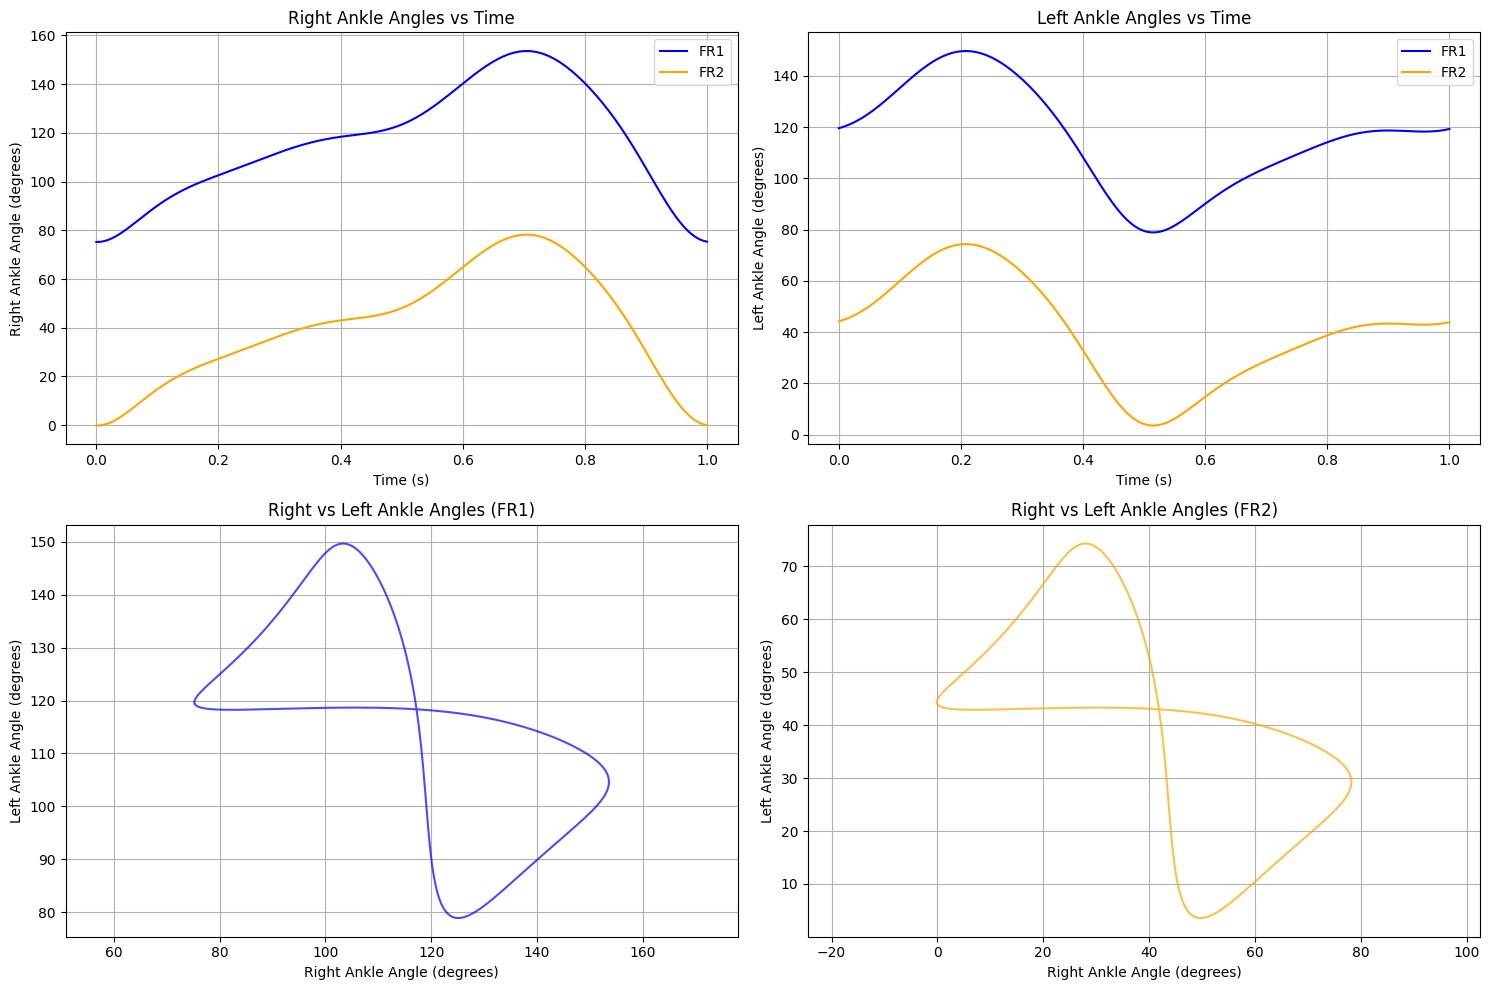

✅ Ankle angle features added successfully!
Right ankle angle range FR1: [75.2, 153.6] degrees
Left ankle angle range FR1: [78.9, 149.7] degrees


In [38]:
# Let's also plot the ankle angles to visualize the new features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot ankle right angles over time for both frames
axes[0, 0].set_title('Right Ankle Angles vs Time')
axes[0, 0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 4], label='FR1', color='blue')
axes[0, 0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 4], label='FR2', color='orange') 
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Right Ankle Angle (degrees)')
axes[0, 0].legend()
axes[0, 0].grid()

# Plot ankle left angles over time for both frames
axes[0, 1].set_title('Left Ankle Angles vs Time')
axes[0, 1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 5], label='FR1', color='blue')
axes[0, 1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 5], label='FR2', color='orange')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Left Ankle Angle (degrees)')
axes[0, 1].legend()
axes[0, 1].grid()

# Plot right vs left ankle angles for FR1
axes[1, 0].set_title('Right vs Left Ankle Angles (FR1)')
axes[1, 0].plot(trajectories_fr1[0][:, 4], trajectories_fr1[0][:, 5], 'b-', alpha=0.7)
axes[1, 0].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 0].set_ylabel('Left Ankle Angle (degrees)')
axes[1, 0].grid()
axes[1, 0].axis('equal')

# Plot right vs left ankle angles for FR2  
axes[1, 1].set_title('Right vs Left Ankle Angles (FR2)')
axes[1, 1].plot(trajectories_fr2[0][:, 4], trajectories_fr2[0][:, 5], 'orange', alpha=0.7)
axes[1, 1].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 1].set_ylabel('Left Ankle Angle (degrees)')
axes[1, 1].grid()
axes[1, 1].axis('equal')

plt.tight_layout()
plt.show()

print("✅ Ankle angle features added successfully!")
print(f"Right ankle angle range FR1: [{trajectories_fr1[0][:, 4].min():.1f}, {trajectories_fr1[0][:, 4].max():.1f}] degrees")
print(f"Left ankle angle range FR1: [{trajectories_fr1[0][:, 5].min():.1f}, {trajectories_fr1[0][:, 5].max():.1f}] degrees")

Ploting Input Data

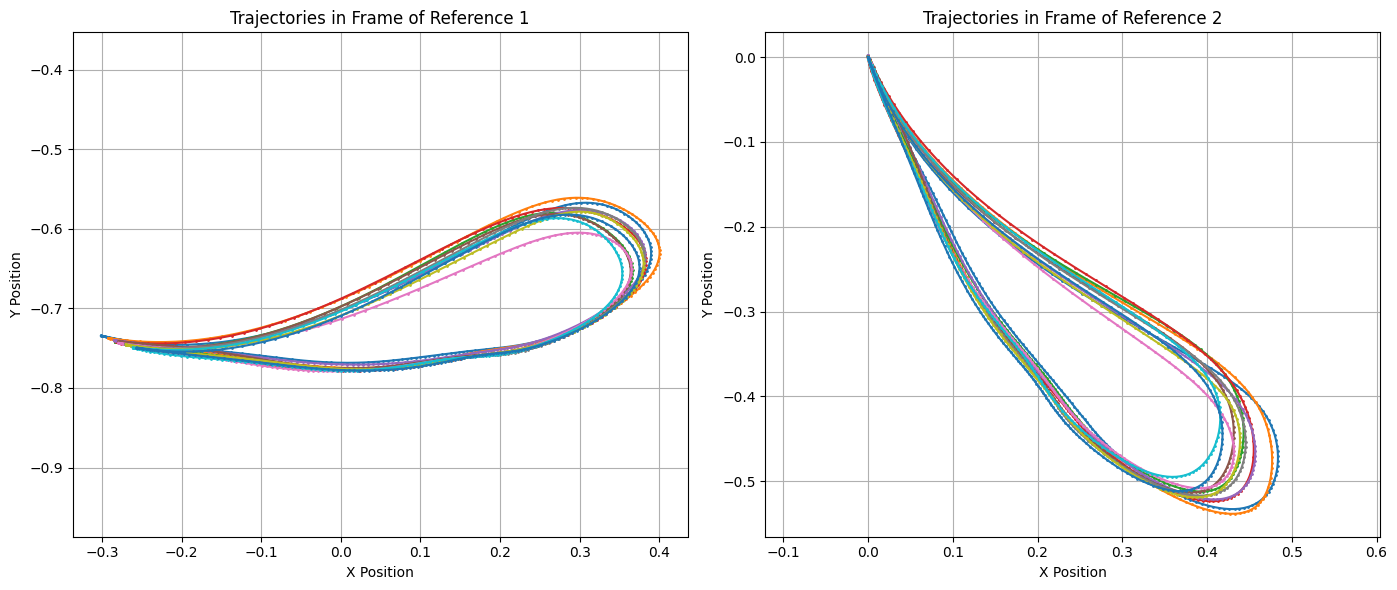

In [39]:
# --- Plotting ---
# Create a figure with two subplots, side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot trajectories for Frame of Reference 1
ax1.set_title('Trajectories in Frame of Reference 1')
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
for traj in trajectories_fr1:
    # The first two columns are x and y ankle positions
    x_pos = traj[:, 0]
    y_pos = traj[:, 1]
    ax1.plot(x_pos, y_pos, marker='.', linestyle='-', markersize=2)
ax1.grid(True)
ax1.axis('equal')

# Plot trajectories for Frame of Reference 2
ax2.set_title('Trajectories in Frame of Reference 2')
ax2.set_xlabel('X Position')
ax2.set_ylabel('Y Position')
for traj in trajectories_fr2:
    # The first two columns are x and y ankle positions
    x_pos = traj[:, 0]
    y_pos = traj[:, 1]
    ax2.plot(x_pos, y_pos, marker='.', linestyle='-', markersize=2)
ax2.grid(True)
ax2.axis('equal')

# Show the plots
fig.tight_layout()
plt.show()

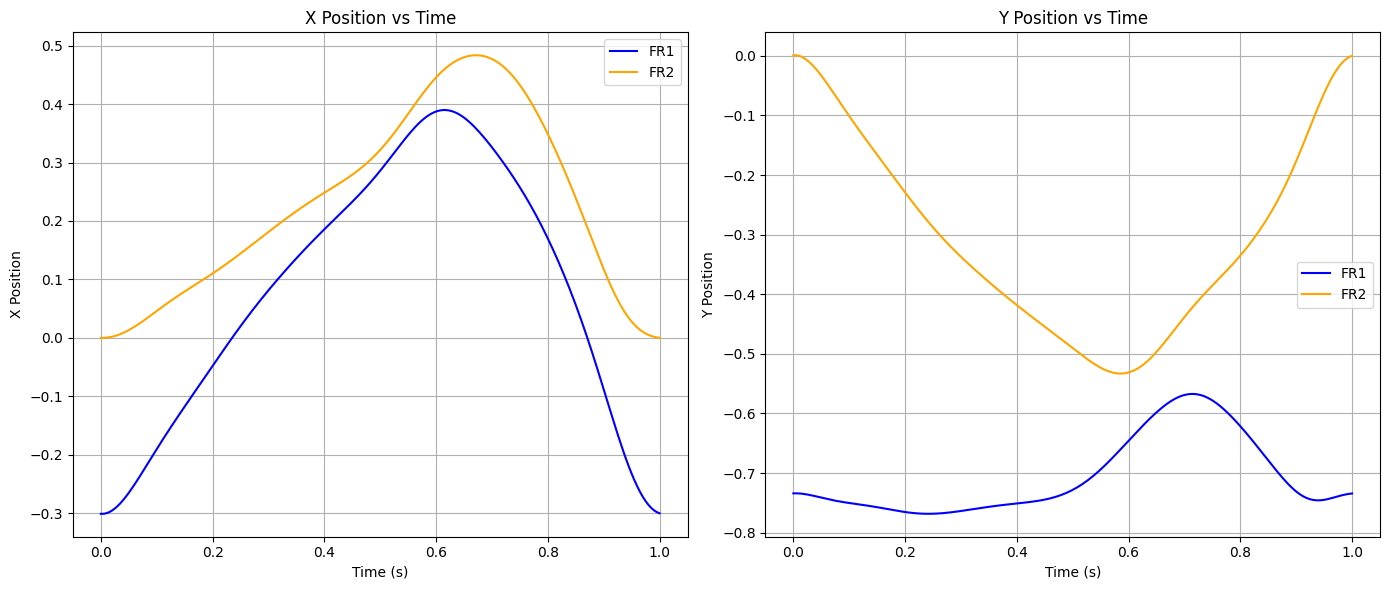

In [40]:
# Create the figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot X vs Time (time is now at index -1, which is index 6)
axs[0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 0], label='FR1', color='blue')
axs[0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 0], label='FR2', color='orange')
axs[0].set_title('X Position vs Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('X Position')
axs[0].legend()
axs[0].grid()

# Plot Y vs Time
axs[1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 1], label='FR1', color='blue')
axs[1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 1], label='FR2', color='orange')
axs[1].set_title('Y Position vs Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Y Position')
axs[1].legend()
axs[1].grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

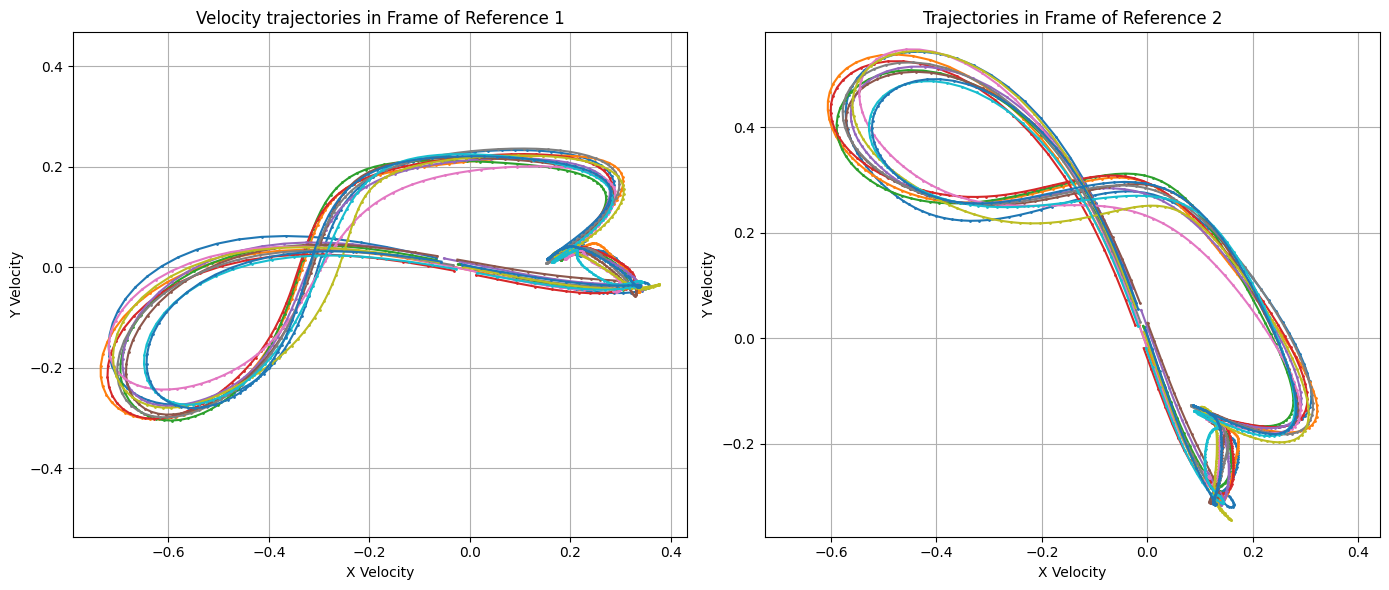

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot velocity trajectories for Frame of Reference 1
ax1.set_title('Velocity trajectories in Frame of Reference 1')
ax1.set_xlabel('X Velocity')
ax1.set_ylabel('Y Velocity')
for traj in trajectories_fr1:
    # Velocity features are at indices 2 and 3
    x_vel = traj[:, 2]
    y_vel = traj[:, 3]
    ax1.plot(x_vel, y_vel, marker='.', linestyle='-', markersize=2)
ax1.grid(True)
ax1.axis('equal')

# Plot velocity trajectories for Frame of Reference 2
ax2.set_title('Trajectories in Frame of Reference 2')
ax2.set_xlabel('X Velocity')
ax2.set_ylabel('Y Velocity')
for traj in trajectories_fr2:
    # Velocity features are at indices 2 and 3
    x_vel = traj[:, 2]
    y_vel = traj[:, 3]
    ax2.plot(x_vel, y_vel, marker='.', linestyle='-', markersize=2)
ax2.grid(True)
ax2.axis('equal')

# Show the plots
plt.tight_layout()
plt.show()

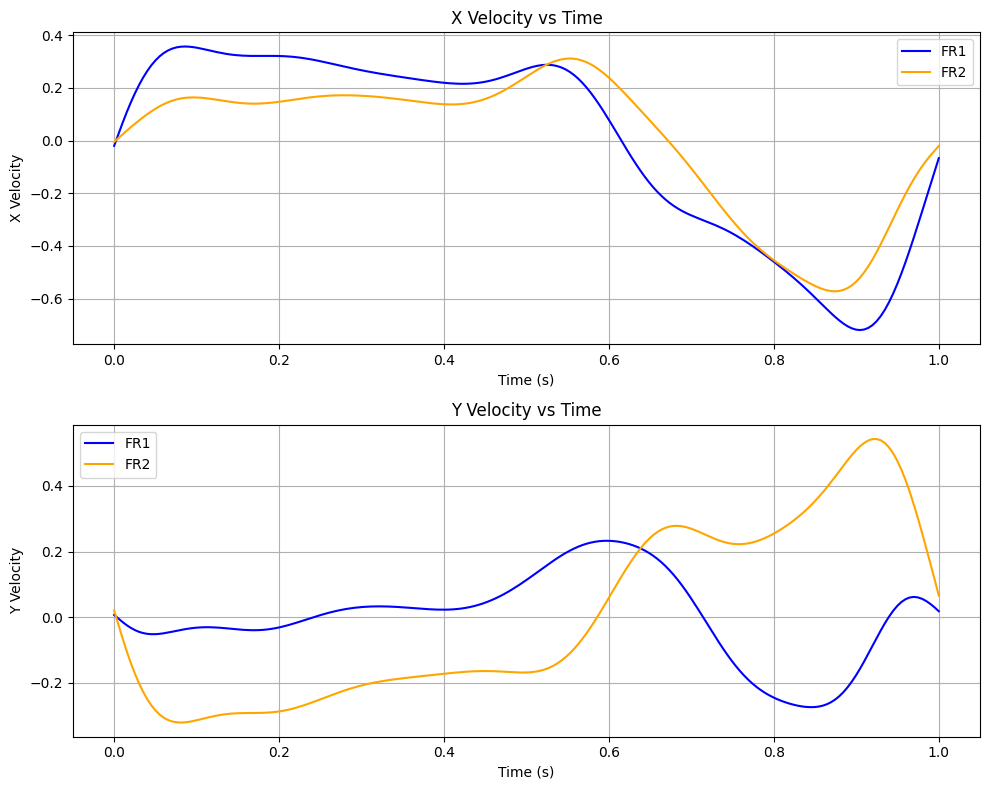

In [42]:
# Create the figure and subplots for velocity plots
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot X velocity vs Time (velocity indices are 2 and 3)
axs[0].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 2], label='FR1', color='blue')
axs[0].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 2], label='FR2', color='orange')
axs[0].set_title('X Velocity vs Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('X Velocity')
axs[0].legend()
axs[0].grid()

# Plot Y velocity vs Time
axs[1].plot(trajectories_fr1[0][:, -1], trajectories_fr1[0][:, 3], label='FR1', color='blue')
axs[1].plot(trajectories_fr2[0][:, -1], trajectories_fr2[0][:, 3], label='FR2', color='orange')
axs[1].set_title('Y Velocity vs Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Y Velocity')
axs[1].legend()
axs[1].grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

TPGMMM

In [43]:
# Reshape the data for TPGMM
# The TPGMM expects data in the shape (num_frames, num_points, num_features)
# We have 2 frames of reference (FR1 and FR2)
# Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time] = 7 features

# Stack the data for the two frames
num_trajectories, num_samples, num_features = trajectories_fr1.shape
reshaped_trajectories = np.stack([trajectories_fr1, trajectories_fr2], axis=0)

# Reshape to (num_frames, num_trajectories * num_samples, num_features)
reshaped_trajectories = reshaped_trajectories.reshape(2, num_trajectories * num_samples, num_features)

print(f"Reshaped trajectories shape: {reshaped_trajectories.shape}")
print(f"Number of features: {num_features}")
print(f"Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")

Reshaped trajectories shape: (2, 2200, 7)
Number of features: 7
Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]


Fitting TPGMM

In [44]:
# Model selection using BIC score for different number of components
best_n_components = None
lowest_bic_score = float('inf')
bic_scores = []
n_components_range = range(3, 15)  # Test components from 3 to 14

print("Starting TPGMM model selection...")
print(f"Testing number of components from {min(n_components_range)} to {max(n_components_range)}")
print(f"Data shape: {reshaped_trajectories.shape}")
print("-" * 60)

# Loop through n_components and collect scores for plotting
for n_components in n_components_range:
    print(f'Fitting TPGMM with n_components={n_components}...')
    
    # Define the TPGMM model with the current n_components
    tpgmm_temp = TPGMM(n_components=n_components, verbose=False, threshold=1e-5, reg_factor=1e-8)
    
    # Fit the model with the trajectories
    print('Data check passed. Fitting the model...')
    tpgmm_temp.fit(reshaped_trajectories)
    
    # Calculate the BIC score
    print('BIC calculation...')
    bic_score = tpgmm_temp.bic(reshaped_trajectories)
    bic_scores.append(bic_score)
    
    print(f'BIC score for n_components={n_components}: {bic_score:.2f}')
    
    # Update the best n_components and lowest BIC score if the current BIC is lower
    if bic_score < lowest_bic_score:
        lowest_bic_score = bic_score
        best_n_components = n_components
        print(f'  -> New best model found!')
    
    print("-" * 60)

# Print the best n_components and the corresponding BIC score
print(f'\\n🎯 OPTIMAL MODEL SELECTION RESULTS:')
print(f'Best n_components: {best_n_components}')
print(f'Lowest BIC score: {lowest_bic_score:.2f}')
print(f'Total models tested: {len(bic_scores)}')

Starting TPGMM model selection...
Testing number of components from 3 to 14
Data shape: (2, 2200, 7)
------------------------------------------------------------
Fitting TPGMM with n_components=3...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=3: 59199.51
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=4...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=4: 52116.16
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=5...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=5: 50132.74
  -> New best model found!
------------------------------------------------------------
Fitting TPGMM with n_components=6...
Data check passed. Fitting the model...
BIC calculation...
BIC score for n_components=6: 48566.18
  -> New best model found!
-------

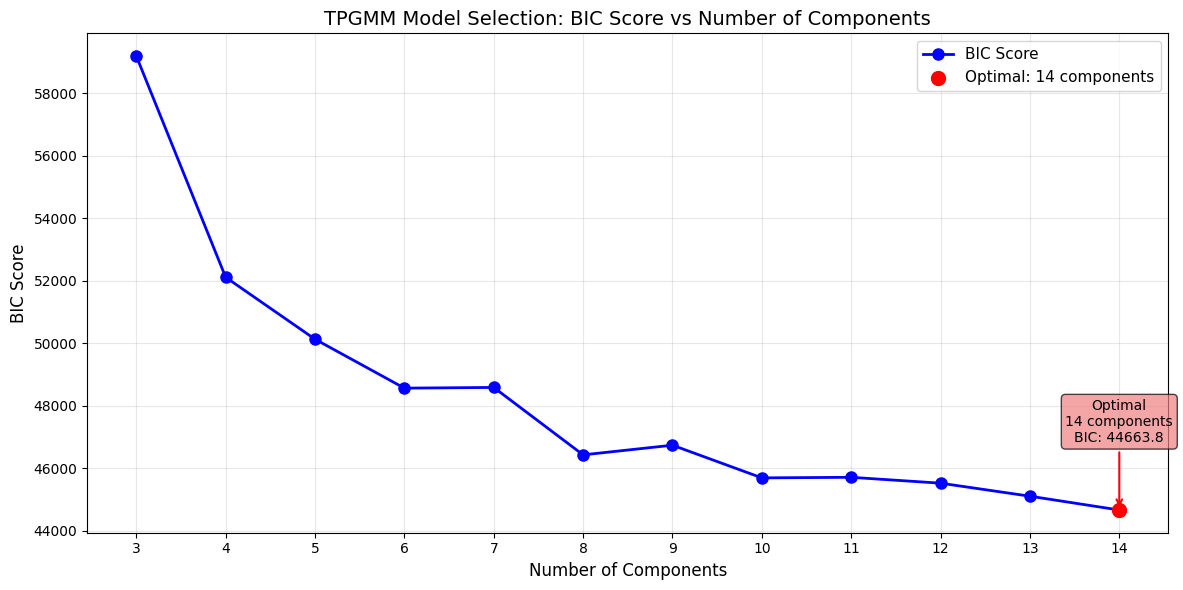

\n📊 BIC SCORES SUMMARY:
Components | BIC Score
----------------------------------------
    3      | 59199.5 
    4      | 52116.2 
    5      | 50132.7 
    6      | 48566.2 
    7      | 48588.5 
    8      | 46430.0 
    9      | 46739.5 
    10     | 45693.1 
    11     | 45711.3 
    12     | 45523.4 
    13     | 45106.3 
    14     | 44663.8  ⭐


In [45]:
# Plot BIC scores for model selection visualization
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot BIC scores
ax.plot(list(n_components_range), bic_scores, 'b-o', linewidth=2, markersize=8, label='BIC Score')
ax.scatter([best_n_components], [lowest_bic_score], color='red', s=100, zorder=5, label=f'Optimal: {best_n_components} components')

# Customize the plot
ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('BIC Score', fontsize=12)
ax.set_title('TPGMM Model Selection: BIC Score vs Number of Components', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add annotation for the optimal point
ax.annotate(f'Optimal\n{best_n_components} components\nBIC: {lowest_bic_score:.1f}', 
            xy=(best_n_components, lowest_bic_score), 
            xytext=(best_n_components, lowest_bic_score + (max(bic_scores) - min(bic_scores)) * 0.15),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

# Set x-axis ticks to show all tested components
ax.set_xticks(list(n_components_range))

plt.tight_layout()
plt.show()

# Display summary table
print("\\n📊 BIC SCORES SUMMARY:")
print("=" * 40)
print("Components | BIC Score")
print("-" * 40)
for i, (n_comp, bic) in enumerate(zip(n_components_range, bic_scores)):
    marker = " ⭐" if n_comp == best_n_components else ""
    print(f"{n_comp:^10} | {bic:^8.1f}{marker}")
print("=" * 40)

In [46]:
print(f'\\nDefining TPGMM with the optimal n_components={best_n_components}...')
tpgmm = TPGMM(n_components=best_n_components, verbose=True, reg_factor=1e-8, threshold=1e-5)
print('Data check passed. Fitting the model...')
tpgmm.fit(reshaped_trajectories)

\nDefining TPGMM with the optimal n_components=14...
Data check passed. Fitting the model...
Started KMeans clustering
finished KMeans clustering
Start expectation maximization
Log likelihood: -32133.261955689868 improvement 37443.87488731189
Log likelihood: -25766.306554422867 improvement 6366.955401267001
Log likelihood: -24727.55013405447 improvement 1038.7564203683978
Log likelihood: -24083.75684407229 improvement 643.793289982179
Log likelihood: -23596.220917750114 improvement 487.53592632217624
Log likelihood: -23353.422355630475 improvement 242.79856211963852
Log likelihood: -23175.728674081183 improvement 177.6936815492918
Log likelihood: -23027.5439280491 improvement 148.18474603208233
Log likelihood: -22934.65092097883 improvement 92.89300707026996
Log likelihood: -22820.628022507637 improvement 114.02289847119391
Log likelihood: -22663.19808885081 improvement 157.4299336568256
Log likelihood: -22507.359522106715 improvement 155.83856674409617
Log likelihood: -22426.995170921

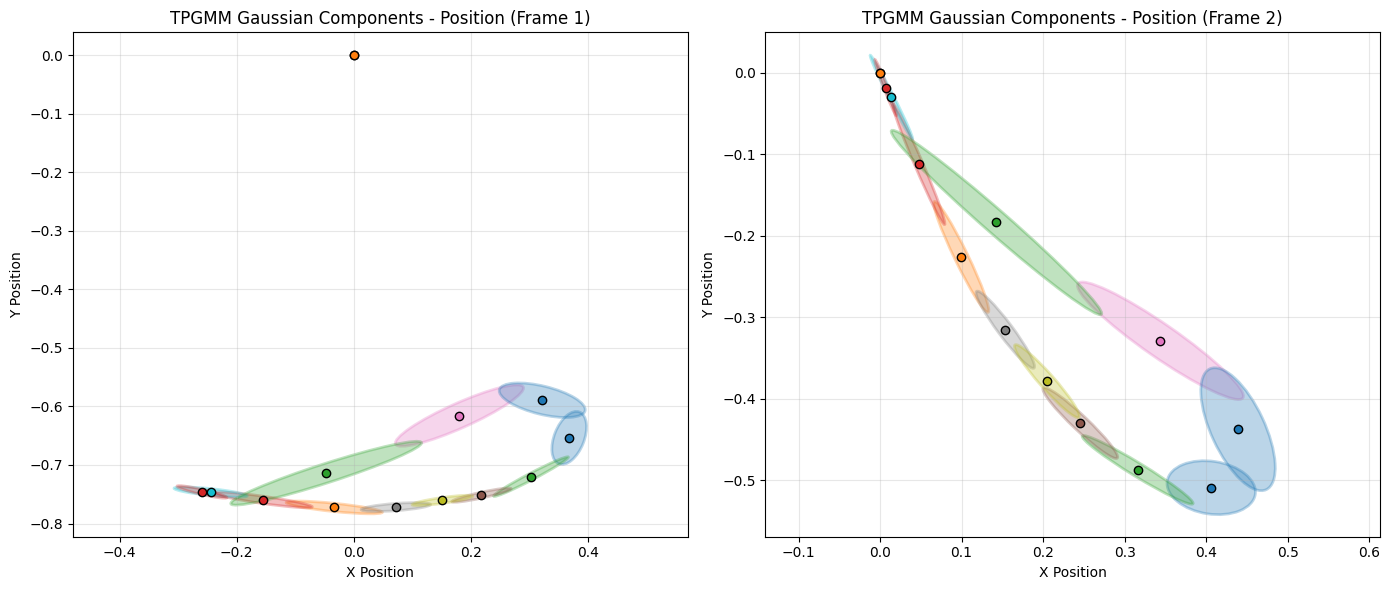

In [47]:
# Visualize TPGMM Gaussian components for position features (indices 0,1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Frame 1 - Position ellipsoids
frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, :2], 
    covs=tpgmm.covariances_[frame_idx, :, :2, :2],
    ax=axes[0]
)
axes[0].set_title('TPGMM Gaussian Components - Position (Frame 1)')
axes[0].set_xlabel('X Position')
axes[0].set_ylabel('Y Position')

# Frame 2 - Position ellipsoids  
frame_idx = 1
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, :2], 
    covs=tpgmm.covariances_[frame_idx, :, :2, :2],
    ax=axes[1]
)
axes[1].set_title('TPGMM Gaussian Components - Position (Frame 2)')
axes[1].set_xlabel('X Position')
axes[1].set_ylabel('Y Position')

plt.tight_layout()
plt.show()

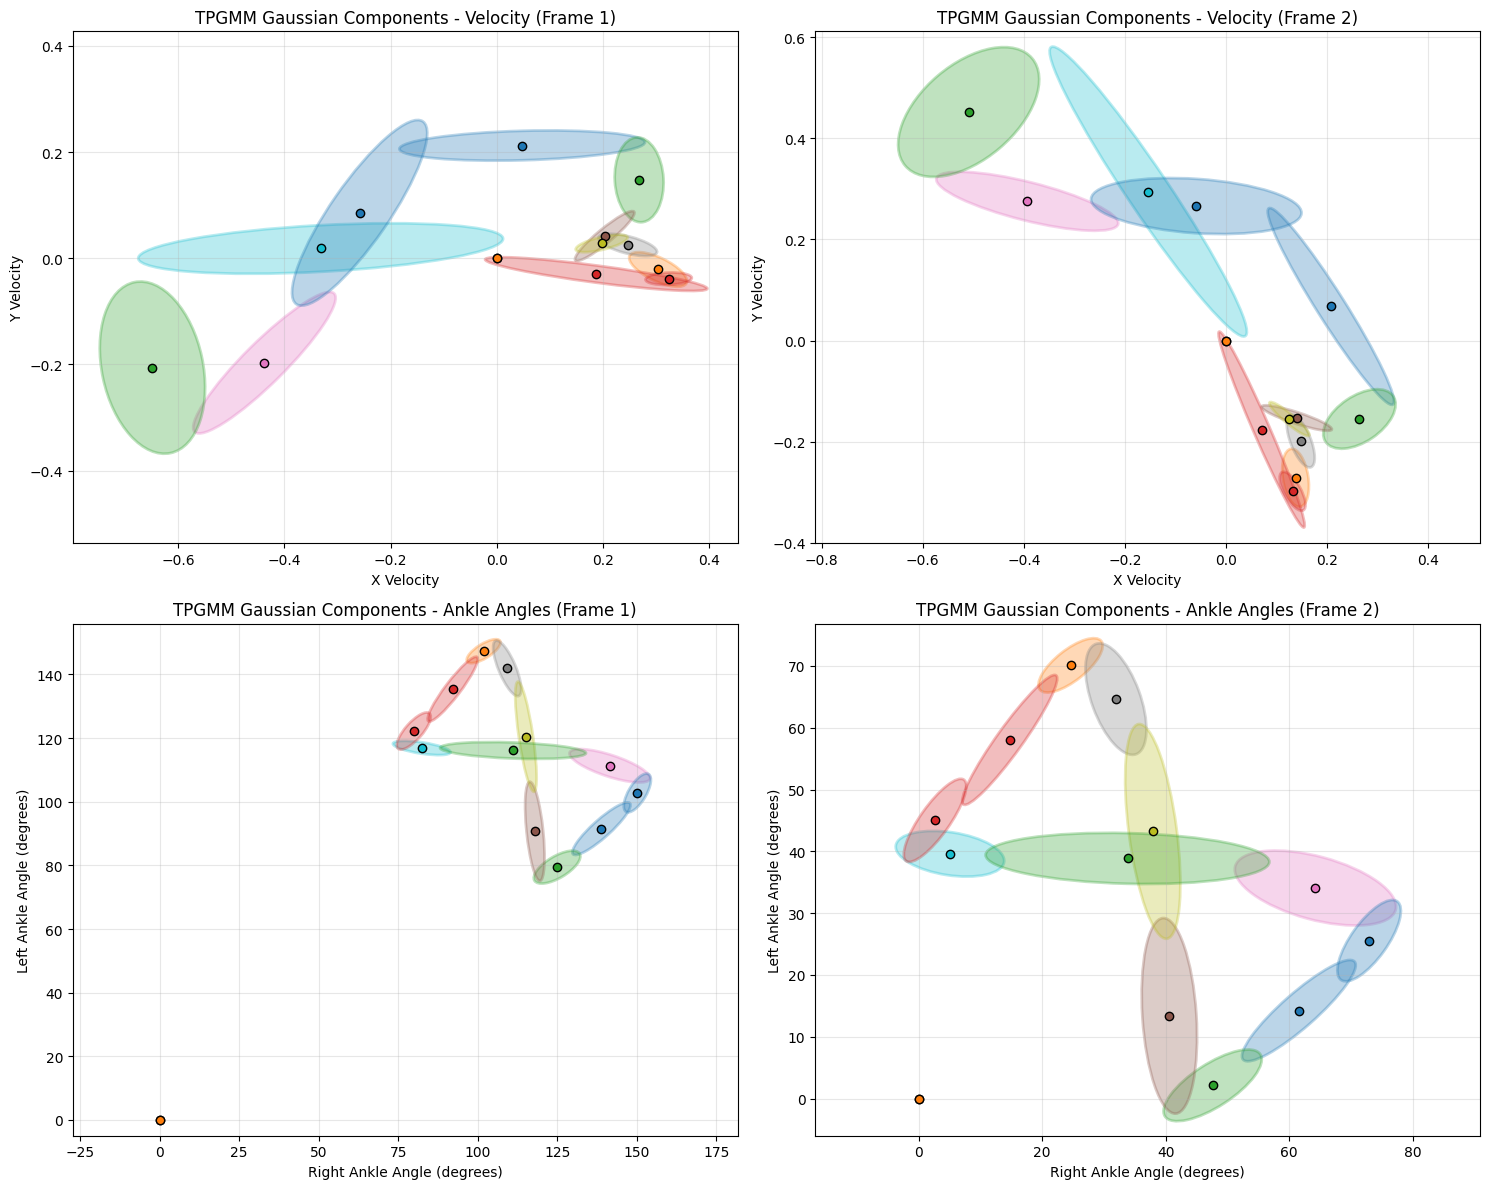

In [48]:
# Visualize TPGMM Gaussian components for velocity and ankle angle features
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Velocity components (indices 2,3)
frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 2:4], 
    covs=tpgmm.covariances_[frame_idx, :, 2:4, 2:4],
    ax=axes[0, 0]
)
axes[0, 0].set_title('TPGMM Gaussian Components - Velocity (Frame 1)')
axes[0, 0].set_xlabel('X Velocity')
axes[0, 0].set_ylabel('Y Velocity')

frame_idx = 1
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 2:4], 
    covs=tpgmm.covariances_[frame_idx, :, 2:4, 2:4],
    ax=axes[0, 1]
)
axes[0, 1].set_title('TPGMM Gaussian Components - Velocity (Frame 2)')
axes[0, 1].set_xlabel('X Velocity')
axes[0, 1].set_ylabel('Y Velocity')

# Ankle angle components (indices 4,5)
frame_idx = 0
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 4:6], 
    covs=tpgmm.covariances_[frame_idx, :, 4:6, 4:6],
    ax=axes[1, 0]
)
axes[1, 0].set_title('TPGMM Gaussian Components - Ankle Angles (Frame 1)')
axes[1, 0].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 0].set_ylabel('Left Ankle Angle (degrees)')

frame_idx = 1
plot_ellipsoids_2d(
    means=tpgmm.means_[frame_idx, :, 4:6], 
    covs=tpgmm.covariances_[frame_idx, :, 4:6, 4:6],
    ax=axes[1, 1]
)
axes[1, 1].set_title('TPGMM Gaussian Components - Ankle Angles (Frame 2)')
axes[1, 1].set_xlabel('Right Ankle Angle (degrees)')
axes[1, 1].set_ylabel('Left Ankle Angle (degrees)')

plt.tight_layout()
plt.show()

Second Part - GMR

In [49]:
# === GMR Data Extraction ===
# Extract a sample trajectory for GMR demonstration
# Using the first trajectory from both frames of reference
sample_trajectory_idx = 0

# Extract trajectory data from our processed trajectories
# Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
traj_fr1 = trajectories_fr1[sample_trajectory_idx]  # Shape: (200, 7)
traj_fr2 = trajectories_fr2[sample_trajectory_idx]  # Shape: (200, 7)

print(f"Sample trajectory shape FR1: {traj_fr1.shape}")
print(f"Sample trajectory shape FR2: {traj_fr2.shape}")
print(f"Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")

# Extract individual components for reference
reference_pos = traj_fr1[:, :2]      # X, Y positions (indices 0, 1)
reference_vel = traj_fr1[:, 2:4]     # X, Y velocities (indices 2, 3)
reference_ankle_right = traj_fr1[:, 4]  # Right ankle angle (index 4)
reference_ankle_left = traj_fr1[:, 5]   # Left ankle angle (index 5)
ref_time = traj_fr1[:, 6]            # Time (index 6)

print(f"Reference components extracted: positions, velocities, ankle angles, time")

# === Calculate Translation and Rotation Between Selected Points ===
print(f"\n" + "="*50)
print("TRAJECTORY TRANSFORMATION ANALYSIS")
print("="*50)

# PARAMETER: Select which time point to analyze (0 = first point, -1 = last point)
selected_point_idx = 0  # Change this value to analyze different points

# Validate index
max_idx = traj_fr1.shape[0] - 1
if selected_point_idx < 0:
    selected_point_idx = max_idx + selected_point_idx + 1  # Handle negative indexing
    
if selected_point_idx < 0 or selected_point_idx > max_idx:
    print(f"⚠️  WARNING: Invalid index {selected_point_idx}. Using index 0 instead.")
    selected_point_idx = 0

print(f"Analyzing point at index: {selected_point_idx} (time: {traj_fr1[selected_point_idx, 6]:.3f})")

# Get selected points of both trajectories
selected_point_fr1 = traj_fr1[selected_point_idx, :2]  # [x_pos, y_pos]
selected_point_fr2 = traj_fr2[selected_point_idx, :2]  # [x_pos, y_pos]
selected_vel_fr1 = traj_fr1[selected_point_idx, 2:4]   # [x_vel, y_vel]
selected_vel_fr2 = traj_fr2[selected_point_idx, 2:4]   # [x_vel, y_vel]

# === Translation Calculation ===
translation_vector = selected_point_fr2 - selected_point_fr1
translation_magnitude = np.linalg.norm(translation_vector)

print(f"\n📍 TRANSLATION (FR1 → FR2):")
print(f"   Vector: [{translation_vector[0]:.4f}, {translation_vector[1]:.4f}]")
print(f"   Magnitude: {translation_magnitude:.4f}")

# === Rotation Calculation ===
def calculate_rotation_angle(vec1, vec2):
    """Calculate rotation angle between two 2D vectors"""
    # Check for zero vectors
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    
    if norm1 < 1e-10 or norm2 < 1e-10:
        return 0.0
    
    # Normalize vectors
    vec1_norm = vec1 / norm1
    vec2_norm = vec2 / norm2
    
    # Calculate angle using dot product and cross product
    dot_product = np.dot(vec1_norm, vec2_norm)
    cross_product = np.cross(vec1_norm, vec2_norm)
    
    # Calculate angle in radians
    angle_rad = np.arctan2(cross_product, dot_product)
    return angle_rad

# Calculate rotation from FR1 to FR2 using velocity vectors
rotation_angle_rad = calculate_rotation_angle(selected_vel_fr1, selected_vel_fr2)
rotation_angle_deg = np.degrees(rotation_angle_rad)

print(f"\n🔄 ROTATION (FR1 → FR2):")
print(f"   Angle: {rotation_angle_rad:.4f} rad ({rotation_angle_deg:.2f}°)")

# Create rotation matrix
cos_theta = np.cos(rotation_angle_rad)
sin_theta = np.sin(rotation_angle_rad)
rotation_matrix = np.array([
    [cos_theta, -sin_theta],
    [sin_theta,  cos_theta]
])

# === Verification: Apply transformation ===
rotated_fr1_pos = rotation_matrix @ selected_point_fr1
transformed_fr1_pos = rotated_fr1_pos + translation_vector
transformation_error = np.linalg.norm(transformed_fr1_pos - selected_point_fr2)

print(f"\n✅ TRANSFORMATION VERIFICATION:")
print(f"   Transformation error: {transformation_error:.6f}")

# === Summary Analysis: Multiple Points ===
print(f"\n📈 TRANSFORMATION SUMMARY AT KEY POINTS:")
analysis_indices = [0, 50, 100, 150, -1]  # Start, quarter points, end
print("Index |  Time  | Translation | Rotation")
print("------|--------|-------------|----------")

for idx in analysis_indices:
    if idx == -1:
        actual_idx = max_idx
    else:
        actual_idx = min(idx, max_idx)
    
    pos1 = traj_fr1[actual_idx, :2]
    pos2 = traj_fr2[actual_idx, :2]
    vel1 = traj_fr1[actual_idx, 2:4]
    vel2 = traj_fr2[actual_idx, 2:4]
    time_val = traj_fr1[actual_idx, 6]
    
    trans_mag = np.linalg.norm(pos2 - pos1)
    rot_angle = np.degrees(calculate_rotation_angle(vel1, vel2))
    
    print(f"{actual_idx:5d} | {time_val:6.3f} | {trans_mag:11.4f} | {rot_angle:8.1f}°")

print("="*50)

Sample trajectory shape FR1: (200, 7)
Sample trajectory shape FR2: (200, 7)
Features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
Reference components extracted: positions, velocities, ankle angles, time

TRAJECTORY TRANSFORMATION ANALYSIS
Analyzing point at index: 0 (time: 0.000)

📍 TRANSLATION (FR1 → FR2):
   Vector: [0.3011, 0.7350]
   Magnitude: 0.7943

🔄 ROTATION (FR1 → FR2):
   Angle: -1.0009 rad (-57.35°)

✅ TRANSFORMATION VERIFICATION:
   Transformation error: 0.761546

📈 TRANSFORMATION SUMMARY AT KEY POINTS:
Index |  Time  | Translation | Rotation
------|--------|-------------|----------
    0 |  0.000 |      0.7943 |    -57.3°
   50 |  0.251 |      0.4947 |    -57.3°
  100 |  0.503 |      0.2374 |    -57.3°
  150 |  0.754 |      0.2654 |    -57.3°
  199 |  1.000 |      0.7935 |    -57.3°


/tmp/ipykernel_54211/2294483070.py:73: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  cross_product = np.cross(vec1_norm, vec2_norm)


In [50]:
# === GMR Instance Setup ===
# Create GMR instance using time as input to predict other features
# In our 7D feature space: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
# We'll use time (index 6) as input and predict the other 6 features

print("Setting up GMR with time as input variable...")
gmr = GaussianMixtureRegression.from_tpgmm(tpgmm, input_idx=[6])  # Time as input

# Verify dimensions
print(f"TPGMM means shape: {tpgmm.means_.shape}")  # Should be (2, n_components, 7)
print(f"TPGMM covariances shape: {tpgmm.covariances_.shape}")  # Should be (2, n_components, 7, 7)
print(f"GMR input dimensions: {gmr.input_idx}")  # Should be [6]
print(f"GMR output dimensions: {gmr.output_idx}")  # Should be [0, 1, 2, 3, 4, 5]
print(f"Number of Gaussian components: {tpgmm.means_.shape[1]}")

# Get number of time steps
num_timesteps = traj_fr1.shape[0]
print(f"Number of time steps: {num_timesteps}")

Setting up GMR with time as input variable...
TPGMM means shape: (2, 14, 7)
TPGMM covariances shape: (2, 14, 7, 7)
GMR input dimensions: [6]
GMR output dimensions: [0, 1, 2, 3, 4, 5]
Number of Gaussian components: 14
Number of time steps: 200


In [51]:
# === GMR Fitting with Transformations ===
print("Setting up GMR transformations...")

# === Original GMR with identity transformation ===
# For 6 output features: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg]
identity_translation = np.zeros((1, 6))  # No translation for 6 output features
identity_translation = identity_translation.repeat(2, axis=0)  # Repeat for both frames

identity_rotation = np.array([np.eye(6)])  # 6x6 identity matrix for 6 output features
identity_rotation = identity_rotation.repeat(2, axis=0)  # Repeat for both frames

print(f"Identity translation shape: {identity_translation.shape}")  # Should be (2, 6)
print(f"Identity rotation shape: {identity_rotation.shape}")  # Should be (2, 6, 6)

# Fit GMR with identity transformation
gmr.fit(translation=identity_translation, rotation_matrix=identity_rotation)
print("✅ Identity GMR fitted successfully")
print("-" * 50)


Setting up GMR transformations...
Identity translation shape: (2, 6)
Identity rotation shape: (2, 6, 6)
fit Rotation matrix shape: (2, 7, 7)
fit Translation shape: (2, 7)
eq5 Sorted means shape: (2, 14, 7)
eq5 Sorted covariances shape: (2, 14, 7, 7)
✅ Identity GMR fitted successfully
--------------------------------------------------


Visualizing GMR fitted Gaussian components...
GMR means shape: (14, 7)
GMR covariances shape: (14, 7, 7)


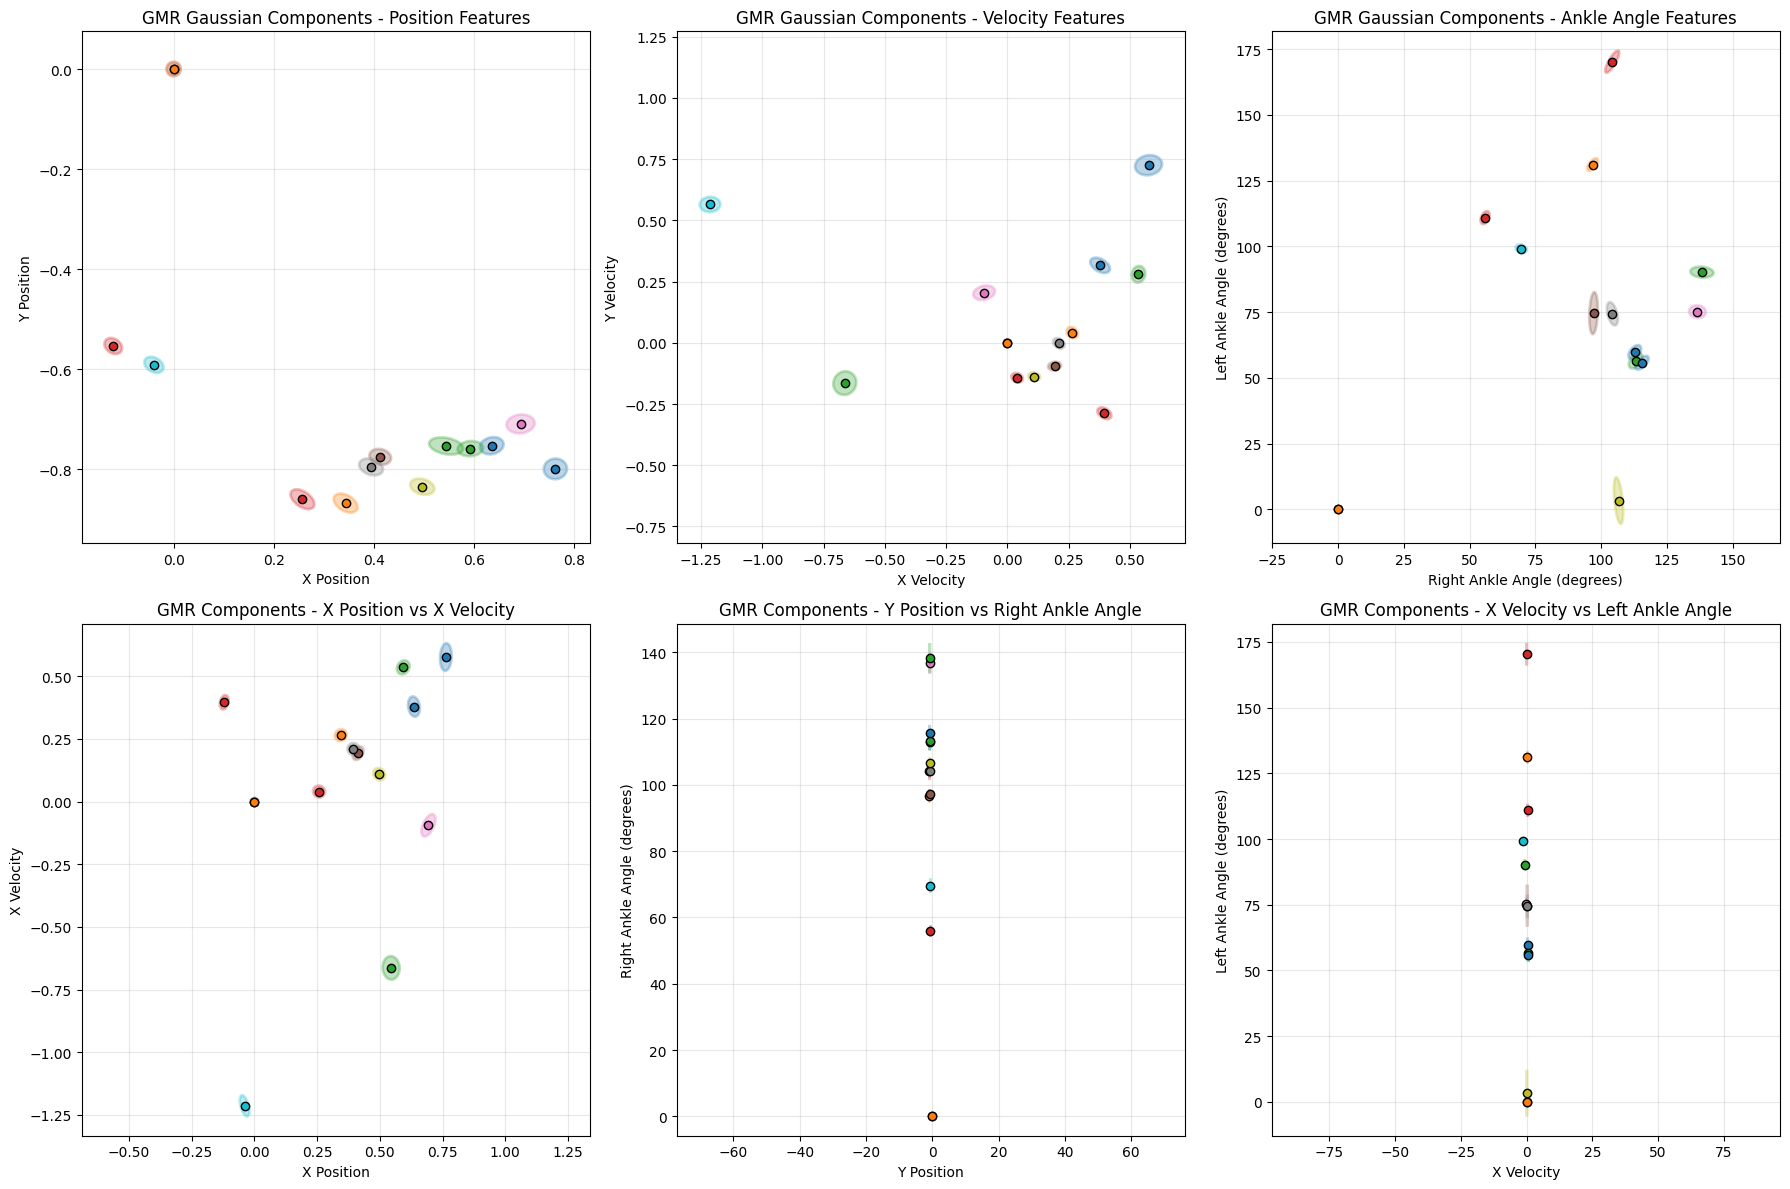


📊 GMR GAUSSIAN COMPONENTS ANALYSIS:
Number of components: 14
Feature dimensions: 7
Component weights (π): [0.07812139 0.09059605 0.08114088 0.09149199 0.         0.07830408
 0.09332931 0.08077534 0.0851043  0.06484144 0.09347166 0.
 0.09472018 0.06810338]

Component means overview:
  X_pos: mean=0.355, std=0.283, range=[-0.121, 0.763]
  Y_pos: mean=-0.647, std=0.278, range=[-0.868, 0.000]
  X_vel: mean=0.052, std=0.460, range=[-1.214, 0.576]
  Y_vel: mean=0.093, std=0.281, range=[-0.288, 0.725]
  R_ankle: mean=89.367, std=42.069, range=[0.000, 138.356]
  L_ankle: mean=71.535, std=47.423, range=[0.000, 170.252]
  Time: mean=0.487, std=0.256, range=[0.000, 0.881]
✅ GMR Gaussian model visualization completed!


In [52]:
# === GMR Gaussian Model Visualization ===
# Visualize the fitted GMR Gaussian components for different feature pairs
print("Visualizing GMR fitted Gaussian components...")
print(f"GMR means shape: {gmr.xi_.shape}")  # Should be (13, 7)
print(f"GMR covariances shape: {gmr.sigma_.shape}")  # Should be (13, 7, 7)

# Create subplots for different feature combinations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Position components (indices 0, 1) - X,Y positions
plot_ellipsoids_2d(
    means=gmr.xi_[:, :2], 
    covs=gmr.sigma_[:, :2, :2],
    ax=axes[0, 0]
)
axes[0, 0].set_title('GMR Gaussian Components - Position Features')
axes[0, 0].set_xlabel('X Position')
axes[0, 0].set_ylabel('Y Position')
axes[0, 0].grid(True)

# Velocity components (indices 2, 3) - X,Y velocities
plot_ellipsoids_2d(
    means=gmr.xi_[:, 2:4], 
    covs=gmr.sigma_[:, 2:4, 2:4],
    ax=axes[0, 1]
)
axes[0, 1].set_title('GMR Gaussian Components - Velocity Features')
axes[0, 1].set_xlabel('X Velocity')
axes[0, 1].set_ylabel('Y Velocity')
axes[0, 1].grid(True)

# Ankle angle components (indices 4, 5) - Right,Left ankle angles
plot_ellipsoids_2d(
    means=gmr.xi_[:, 4:6], 
    covs=gmr.sigma_[:, 4:6, 4:6],
    ax=axes[0, 2]
)
axes[0, 2].set_title('GMR Gaussian Components - Ankle Angle Features')
axes[0, 2].set_xlabel('Right Ankle Angle (degrees)')
axes[0, 2].set_ylabel('Left Ankle Angle (degrees)')
axes[0, 2].grid(True)

# Mixed feature combinations for additional insights
# Position vs Velocity (X components)
plot_ellipsoids_2d(
    means=gmr.xi_[:, [0, 2]], 
    covs=gmr.sigma_[:, [0, 2], :][:, :, [0, 2]],
    ax=axes[1, 0]
)
axes[1, 0].set_title('GMR Components - X Position vs X Velocity')
axes[1, 0].set_xlabel('X Position')
axes[1, 0].set_ylabel('X Velocity')
axes[1, 0].grid(True)

# Position vs Ankle Angle (Y position vs Right ankle)
plot_ellipsoids_2d(
    means=gmr.xi_[:, [1, 4]], 
    covs=gmr.sigma_[:, [1, 4], :][:, :, [1, 4]],
    ax=axes[1, 1]
)
axes[1, 1].set_title('GMR Components - Y Position vs Right Ankle Angle')
axes[1, 1].set_xlabel('Y Position')
axes[1, 1].set_ylabel('Right Ankle Angle (degrees)')
axes[1, 1].grid(True)

# Velocity vs Ankle Angle (X velocity vs Left ankle)
plot_ellipsoids_2d(
    means=gmr.xi_[:, [2, 5]], 
    covs=gmr.sigma_[:, [2, 5], :][:, :, [2, 5]],
    ax=axes[1, 2]
)
axes[1, 2].set_title('GMR Components - X Velocity vs Left Ankle Angle')
axes[1, 2].set_xlabel('X Velocity')
axes[1, 2].set_ylabel('Left Ankle Angle (degrees)')
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

# Print component statistics
print(f"\n📊 GMR GAUSSIAN COMPONENTS ANALYSIS:")
print(f"Number of components: {gmr.xi_.shape[0]}")
print(f"Feature dimensions: {gmr.xi_.shape[1]}")
print(f"Component weights (π): {gmr.gmm_weights}")
print("\nComponent means overview:")
feature_names = ['X_pos', 'Y_pos', 'X_vel', 'Y_vel', 'R_ankle', 'L_ankle', 'Time']
for i, feature in enumerate(feature_names):
    means_for_feature = gmr.xi_[:, i]
    print(f"  {feature}: mean={means_for_feature.mean():.3f}, std={means_for_feature.std():.3f}, range=[{means_for_feature.min():.3f}, {means_for_feature.max():.3f}]")

print("✅ GMR Gaussian model visualization completed!")

In [53]:
# === Transformed GMR ===
# Create a second GMR instance with transformations
gmr_transformed = GaussianMixtureRegression.from_tpgmm(tpgmm, input_idx=[6])

# Define transformation parameters
angle_transform = np.radians(18)  # 18-degree rotation (similar to our data rotation)
print(f"Transformation angle: {angle_transform:.4f} radians ({np.degrees(angle_transform):.1f} degrees)")

# Create 2D rotation matrix for position and velocity
cos_theta = np.cos(angle_transform)
sin_theta = np.sin(angle_transform)
rot_2d_transform = np.array([
    [cos_theta, -sin_theta],
    [sin_theta,  cos_theta]
])

# Create 6D transformation matrix for all output features
rot_6d_transform = np.eye(6)
rot_6d_transform[0:2, 0:2] = rot_2d_transform  # Rotate position (indices 0, 1)
rot_6d_transform[2:4, 2:4] = rot_2d_transform  # Rotate velocity (indices 2, 3)
# Ankle angles (indices 4, 5) remain unchanged

print(f"2D rotation matrix:")
print(rot_2d_transform)
print(f"6D transformation matrix:")
print(rot_6d_transform)

# Define translation and rotation for both frames
# Frame 1: identity, Frame 2: transformation
transform_translation = np.array([
    [0, 0, 0, 0, 0, 0],  # Frame 1: no translation
    [0.1, 0.1, 0, 0, 0, 0]  # Frame 2: small translation for position only
])

transform_rotation = np.array([
    np.eye(6),  # Frame 1: identity
    rot_6d_transform  # Frame 2: transformation
])

print(f"Transform translation shape: {transform_translation.shape}")
print(f"Transform rotation shape: {transform_rotation.shape}")

# Fit transformed GMR
gmr_transformed.fit(translation=transform_translation, rotation_matrix=transform_rotation)
print("✅ Transformed GMR fitted successfully")

# Print fitted GMR properties
print(f"\\nGMR means shape: {gmr.xi_.shape}")
print(f"GMR covariances shape: {gmr.sigma_.shape}")
print(f"Transformed GMR means shape: {gmr_transformed.xi_.shape}")
print(f"Transformed GMR covariances shape: {gmr_transformed.sigma_.shape}")

Transformation angle: 0.3142 radians (18.0 degrees)
2D rotation matrix:
[[ 0.95105652 -0.30901699]
 [ 0.30901699  0.95105652]]
6D transformation matrix:
[[ 0.95105652 -0.30901699  0.          0.          0.          0.        ]
 [ 0.30901699  0.95105652  0.          0.          0.          0.        ]
 [ 0.          0.          0.95105652 -0.30901699  0.          0.        ]
 [ 0.          0.          0.30901699  0.95105652  0.          0.        ]
 [ 0.          0.          0.          0.          1.          0.        ]
 [ 0.          0.          0.          0.          0.          1.        ]]
Transform translation shape: (2, 6)
Transform rotation shape: (2, 6, 6)
fit Rotation matrix shape: (2, 7, 7)
fit Translation shape: (2, 7)
eq5 Sorted means shape: (2, 14, 7)
eq5 Sorted covariances shape: (2, 14, 7, 7)
✅ Transformed GMR fitted successfully
\nGMR means shape: (14, 7)
GMR covariances shape: (14, 7, 7)
Transformed GMR means shape: (14, 7)
Transformed GMR covariances shape: (14, 7,

In [54]:
# === GMR Predictions ===
# Generate predictions using both GMR models with time as input

print("Generating GMR predictions...")

# Prepare time input
time_input = ref_time.reshape(-1, 1)  # Shape: (200, 1)
print(f"Time input shape: {time_input.shape}")

# === Original GMR Predictions ===
pred_orig_output, pred_original_cov = gmr.predict(time_input)
print(f"Original prediction output shape: {pred_orig_output.shape}")  # Should be (200, 6)
print(f"Original prediction covariance shape: {pred_original_cov.shape}")  # Should be (200, 6, 6)

# Extract individual predicted features
pred_orig_pos = pred_orig_output[:, :2]  # X, Y positions
pred_orig_vel = pred_orig_output[:, 2:4]  # X, Y velocities  
pred_orig_ankle_right = pred_orig_output[:, 4]  # Right ankle angle
pred_orig_ankle_left = pred_orig_output[:, 5]   # Left ankle angle

print(f"Predicted position shape: {pred_orig_pos.shape}")
print(f"Predicted velocity shape: {pred_orig_vel.shape}")
print(f"Predicted right ankle shape: {pred_orig_ankle_right.shape}")
print(f"Predicted left ankle shape: {pred_orig_ankle_left.shape}")

# === Transformed GMR Predictions ===
pred_trans_output, pred_transformed_cov = gmr_transformed.predict(time_input)
print(f"Transformed prediction output shape: {pred_trans_output.shape}")
print(f"Transformed prediction covariance shape: {pred_transformed_cov.shape}")

# Extract individual predicted features for transformed model
pred_trans_pos = pred_trans_output[:, :2]  # X, Y positions
pred_trans_vel = pred_trans_output[:, 2:4]  # X, Y velocities
pred_trans_ankle_right = pred_trans_output[:, 4]  # Right ankle angle
pred_trans_ankle_left = pred_trans_output[:, 5]   # Left ankle angle

print("✅ GMR predictions generated successfully!")

# === Calculate prediction errors ===
pos_error_orig = np.linalg.norm(pred_orig_pos - reference_pos, axis=1)
pos_error_trans = np.linalg.norm(pred_trans_pos - reference_pos, axis=1)

ankle_right_error_orig = np.abs(pred_orig_ankle_right - reference_ankle_right)
ankle_left_error_orig = np.abs(pred_orig_ankle_left - reference_ankle_left)

print(f"\\nPrediction Error Analysis:")
print(f"Position RMSE (Original): {np.sqrt(np.mean(pos_error_orig**2)):.4f}")
print(f"Position RMSE (Transformed): {np.sqrt(np.mean(pos_error_trans**2)):.4f}")
print(f"Right Ankle MAE (Original): {np.mean(ankle_right_error_orig):.4f}°")
print(f"Left Ankle MAE (Original): {np.mean(ankle_left_error_orig):.4f}°")

Generating GMR predictions...
Time input shape: (200, 1)
Original prediction output shape: (200, 6)
Original prediction covariance shape: (200, 6, 6)
Predicted position shape: (200, 2)
Predicted velocity shape: (200, 2)
Predicted right ankle shape: (200,)
Predicted left ankle shape: (200,)
Transformed prediction output shape: (200, 6)
Transformed prediction covariance shape: (200, 6, 6)
✅ GMR predictions generated successfully!
\nPrediction Error Analysis:
Position RMSE (Original): 0.2547
Position RMSE (Transformed): 0.8107
Right Ankle MAE (Original): 28.1910°
Left Ankle MAE (Original): 33.1108°


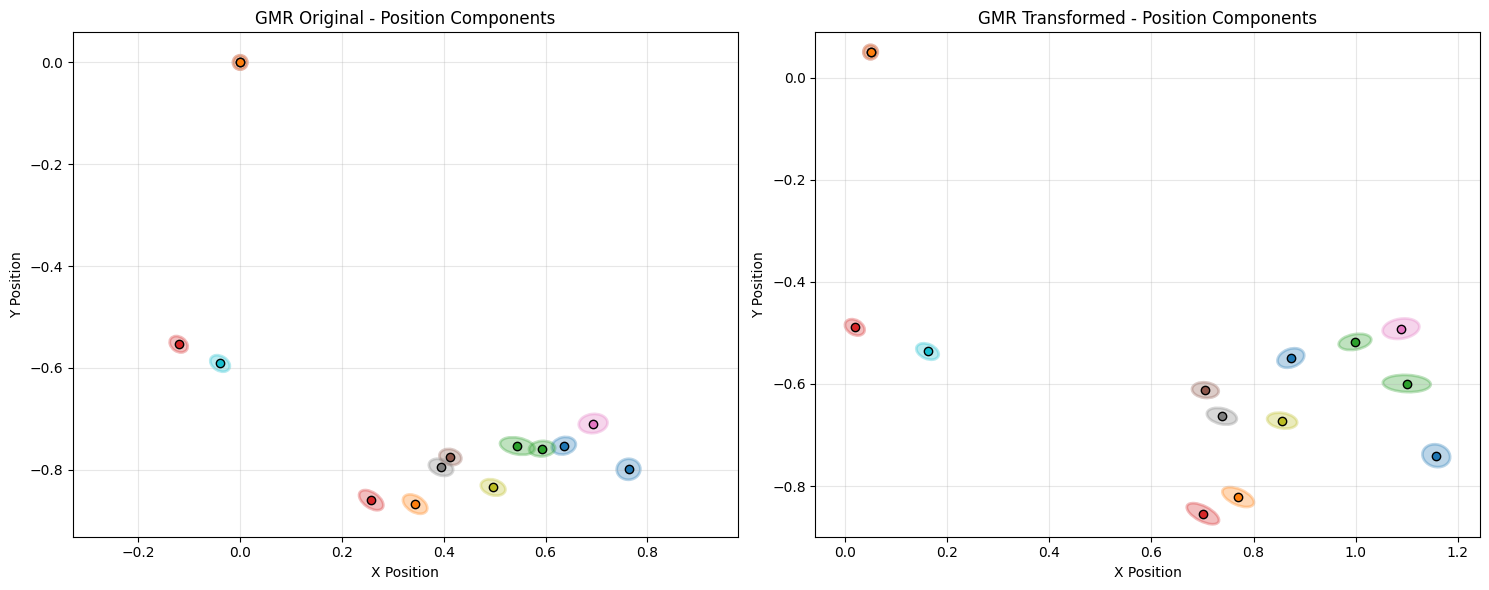

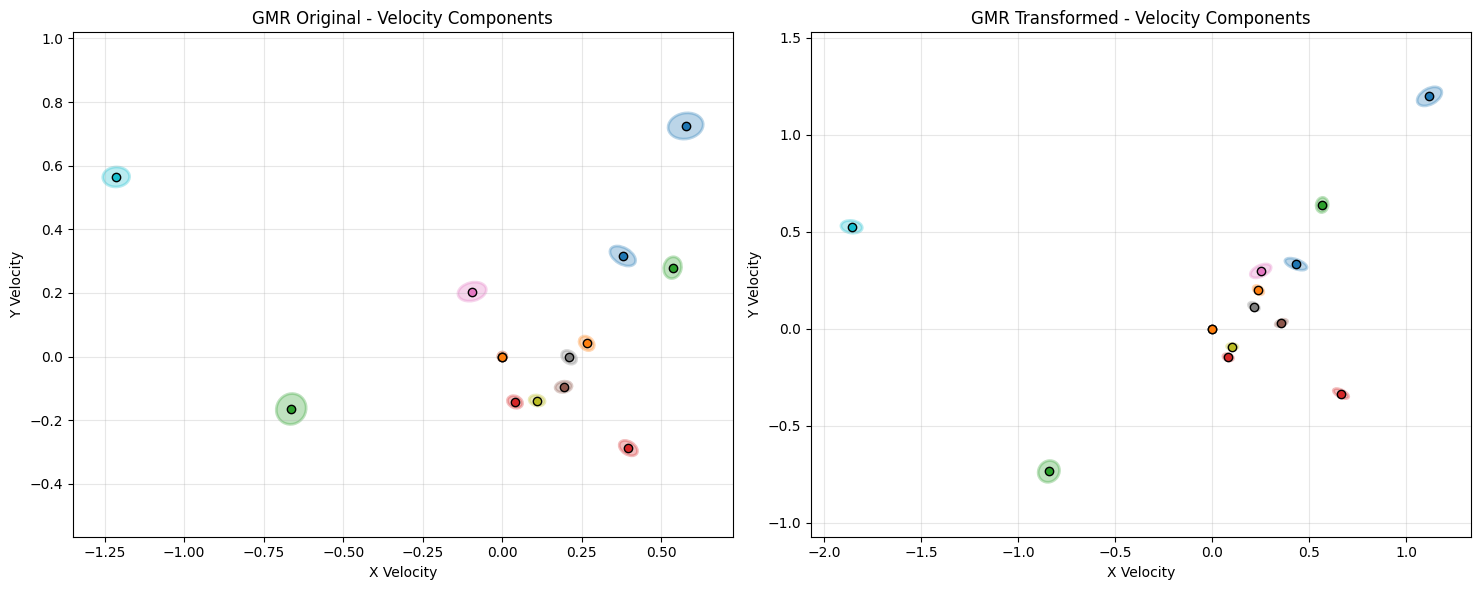

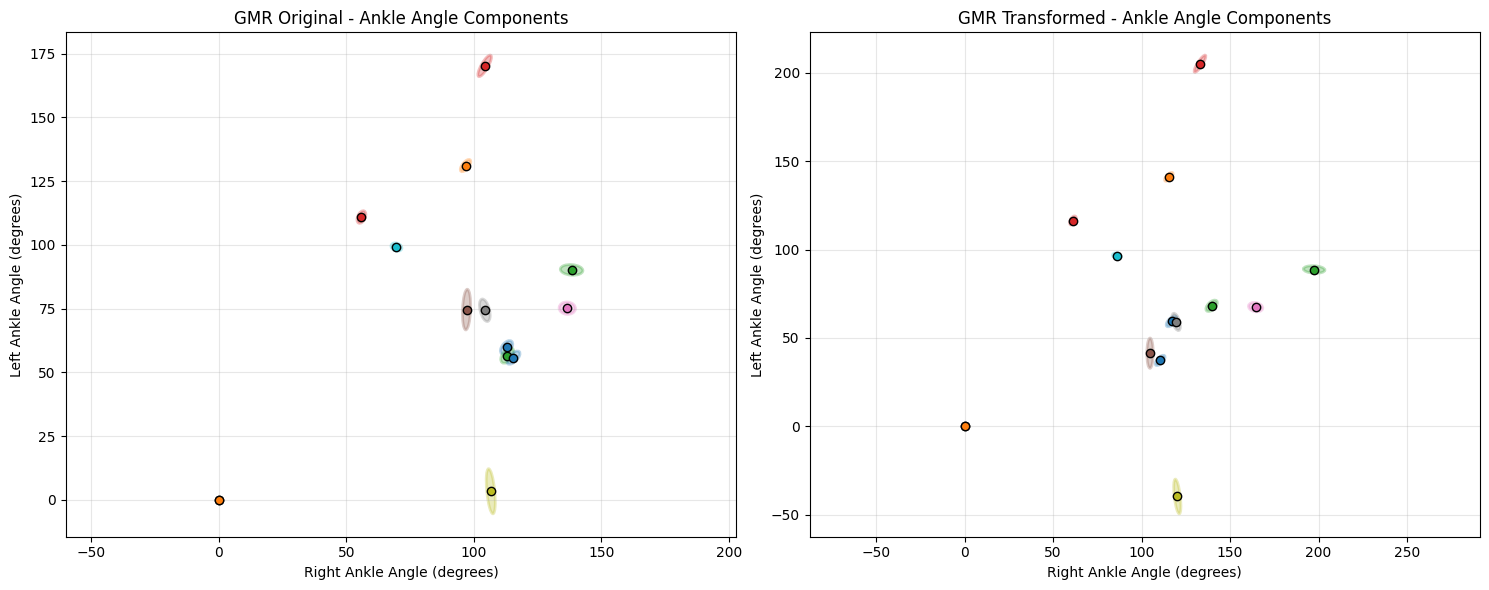

In [55]:
# === GMR Gaussian Components Visualization ===
# Visualize the learned GMR components for different feature pairs

# Plot position components (indices 0, 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original GMR position components
plot_ellipsoids_2d(
    means=gmr.xi_[:, :2], 
    covs=gmr.sigma_[:, :2, :2],
    ax=axes[0]
)
axes[0].set_title('GMR Original - Position Components')
axes[0].set_xlabel('X Position')
axes[0].set_ylabel('Y Position')
axes[0].grid(True)

# Transformed GMR position components
plot_ellipsoids_2d(
    means=gmr_transformed.xi_[:, :2], 
    covs=gmr_transformed.sigma_[:, :2, :2],
    ax=axes[1]
)
axes[1].set_title('GMR Transformed - Position Components')
axes[1].set_xlabel('X Position')
axes[1].set_ylabel('Y Position')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plot velocity components (indices 2, 3)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original GMR velocity components
plot_ellipsoids_2d(
    means=gmr.xi_[:, 2:4], 
    covs=gmr.sigma_[:, 2:4, 2:4],
    ax=axes[0]
)
axes[0].set_title('GMR Original - Velocity Components')
axes[0].set_xlabel('X Velocity')
axes[0].set_ylabel('Y Velocity')
axes[0].grid(True)

# Transformed GMR velocity components
plot_ellipsoids_2d(
    means=gmr_transformed.xi_[:, 2:4], 
    covs=gmr_transformed.sigma_[:, 2:4, 2:4],
    ax=axes[1]
)
axes[1].set_title('GMR Transformed - Velocity Components')
axes[1].set_xlabel('X Velocity')
axes[1].set_ylabel('Y Velocity')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plot ankle angle components (indices 4, 5)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original GMR ankle angle components
plot_ellipsoids_2d(
    means=gmr.xi_[:, 4:6], 
    covs=gmr.sigma_[:, 4:6, 4:6],
    ax=axes[0]
)
axes[0].set_title('GMR Original - Ankle Angle Components')
axes[0].set_xlabel('Right Ankle Angle (degrees)')
axes[0].set_ylabel('Left Ankle Angle (degrees)')
axes[0].grid(True)

# Transformed GMR ankle angle components
plot_ellipsoids_2d(
    means=gmr_transformed.xi_[:, 4:6], 
    covs=gmr_transformed.sigma_[:, 4:6, 4:6],
    ax=axes[1]
)
axes[1].set_title('GMR Transformed - Ankle Angle Components')
axes[1].set_xlabel('Right Ankle Angle (degrees)')
axes[1].set_ylabel('Left Ankle Angle (degrees)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_54211/4252121998.py:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


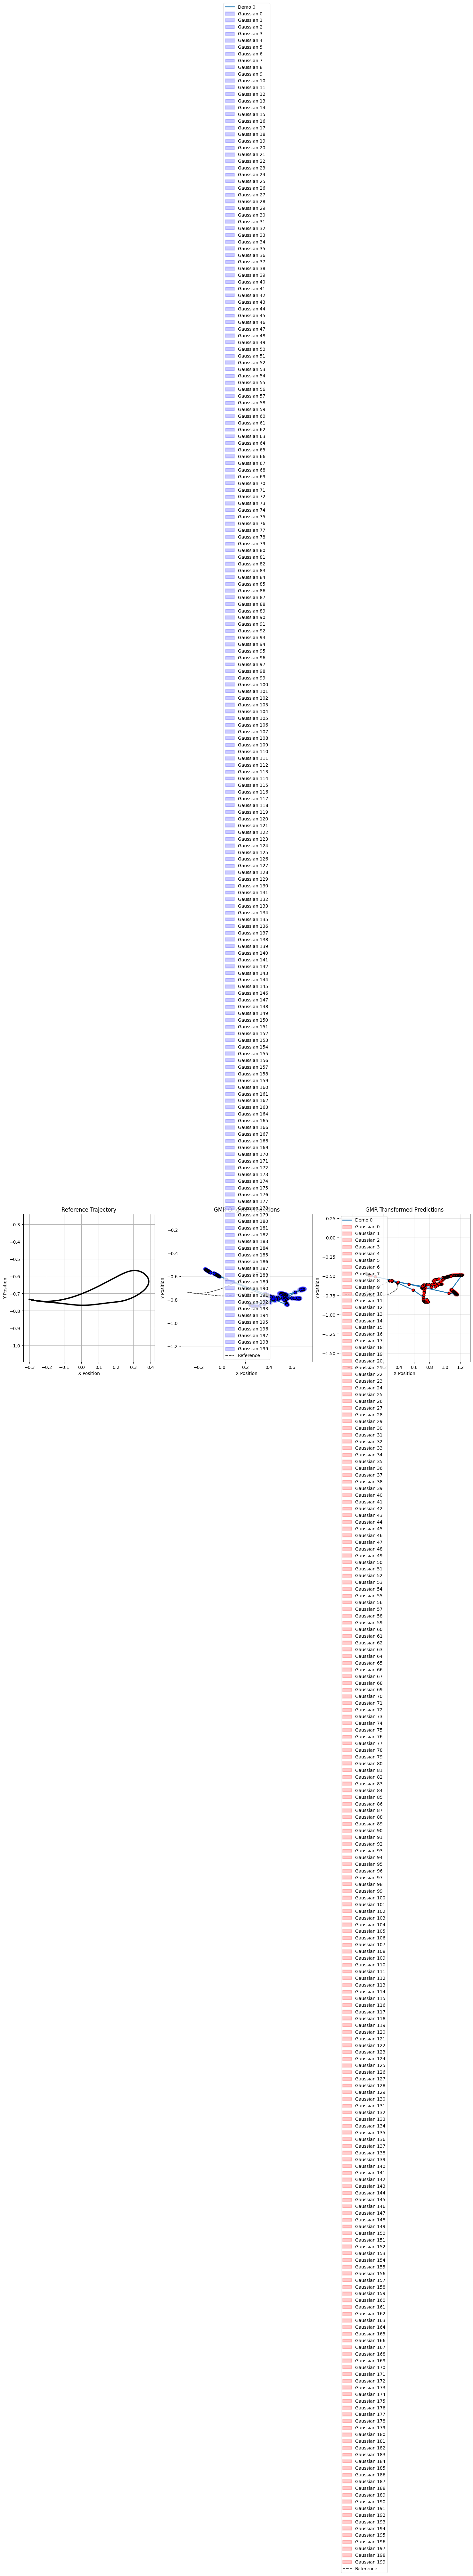

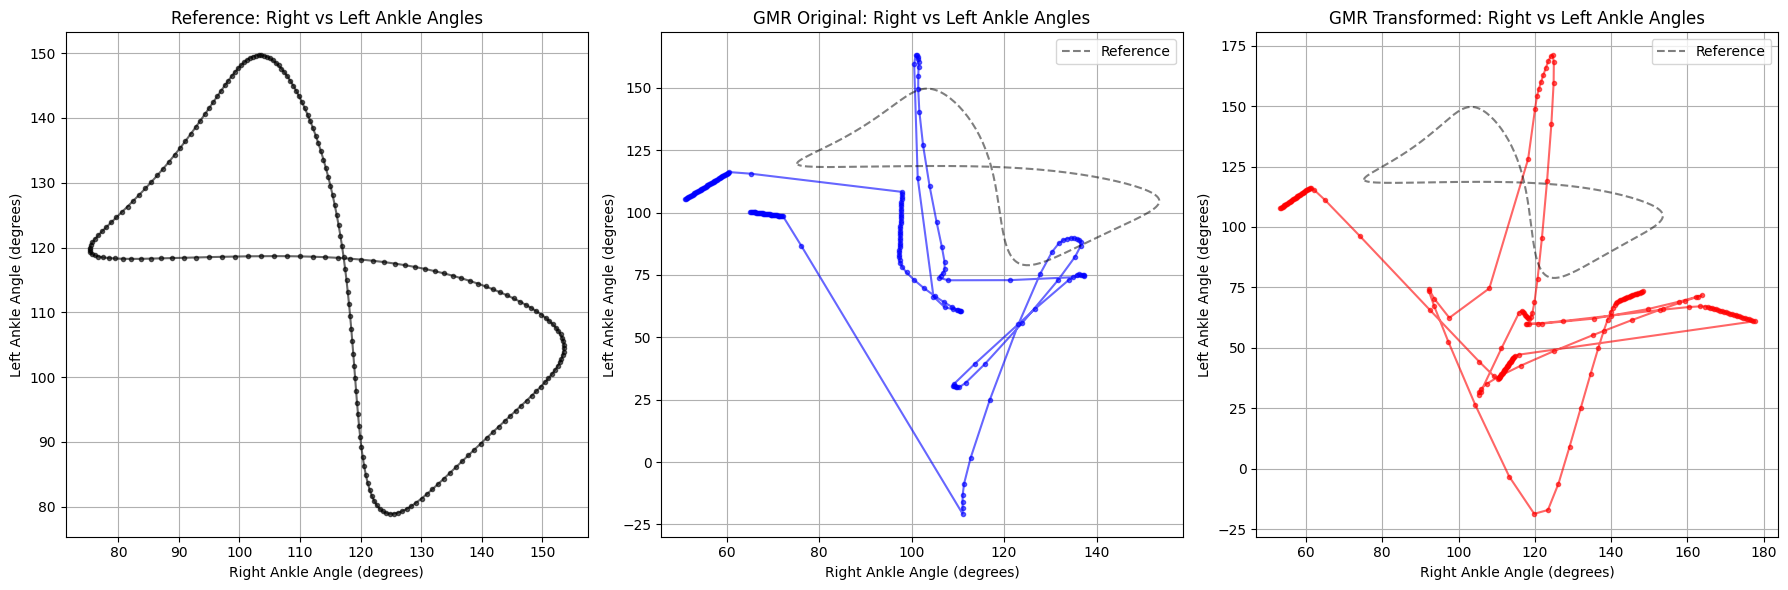

🎯 GMR Analysis Complete!
✅ Successfully demonstrated TPGMM-based GMR with 14 components
✅ Processed 11 demonstrations with 7 features each
✅ Features: position, velocity, and ankle angles
✅ Applied coordinate transformations and generated predictions


In [56]:
# === Trajectory Visualization with Uncertainty ===
# Create trajectory plots with uncertainty visualization
from tpgmm.utils.plot.plot import plot_trajectories_2d

# Create X-Y trajectory comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Reference trajectory
axes[0].plot(reference_pos[:, 0], reference_pos[:, 1], 'k-', label='Reference', linewidth=3)
axes[0].set_title('Reference Trajectory')
axes[0].set_xlabel('X Position')
axes[0].set_ylabel('Y Position')
axes[0].grid(True)
axes[0].axis('equal')

# Original GMR predictions with uncertainty
trajectories_original = pred_orig_pos.reshape(1, -1, 2)  # Reshape for plot_trajectories_2d
axes[1].set_title('GMR Original Predictions')
plot_trajectories_2d(trajectories=trajectories_original, ax=axes[1])
plot_ellipsoids_2d(
    means=pred_orig_pos,
    covs=pred_original_cov[:, :2, :2],
    ax=axes[1],
    alpha=0.2,
    color='blue'
)
axes[1].plot(reference_pos[:, 0], reference_pos[:, 1], 'k--', label='Reference', alpha=0.7)
axes[1].set_xlabel('X Position')
axes[1].set_ylabel('Y Position')
axes[1].legend()
axes[1].grid(True)
axes[1].axis('equal')

# Transformed GMR predictions with uncertainty
trajectories_transformed = pred_trans_pos.reshape(1, -1, 2)  # Reshape for plot_trajectories_2d
axes[2].set_title('GMR Transformed Predictions')
plot_trajectories_2d(trajectories=trajectories_transformed, ax=axes[2])
plot_ellipsoids_2d(
    means=pred_trans_pos,
    covs=pred_transformed_cov[:, :2, :2],
    ax=axes[2],
    alpha=0.2,
    color='red'
)
axes[2].plot(reference_pos[:, 0], reference_pos[:, 1], 'k--', label='Reference', alpha=0.7)
axes[2].set_xlabel('X Position')
axes[2].set_ylabel('Y Position')
axes[2].legend()
axes[2].grid(True)
axes[2].axis('equal')

plt.tight_layout()
plt.show()

# === Ankle Angle Correlation Analysis ===
# Analyze the relationship between right and left ankle angles
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Reference ankle angle correlation
axes[0].plot(reference_ankle_right, reference_ankle_left, 'ko-', alpha=0.6, markersize=3)
axes[0].set_title('Reference: Right vs Left Ankle Angles')
axes[0].set_xlabel('Right Ankle Angle (degrees)')
axes[0].set_ylabel('Left Ankle Angle (degrees)')
axes[0].grid(True)

# Original GMR ankle angle correlation
axes[1].plot(pred_orig_ankle_right, pred_orig_ankle_left, 'bo-', alpha=0.6, markersize=3)
axes[1].plot(reference_ankle_right, reference_ankle_left, 'k--', alpha=0.5, label='Reference')
axes[1].set_title('GMR Original: Right vs Left Ankle Angles')
axes[1].set_xlabel('Right Ankle Angle (degrees)')
axes[1].set_ylabel('Left Ankle Angle (degrees)')
axes[1].legend()
axes[1].grid(True)

# Transformed GMR ankle angle correlation
axes[2].plot(pred_trans_ankle_right, pred_trans_ankle_left, 'ro-', alpha=0.6, markersize=3)
axes[2].plot(reference_ankle_right, reference_ankle_left, 'k--', alpha=0.5, label='Reference')
axes[2].set_title('GMR Transformed: Right vs Left Ankle Angles')
axes[2].set_xlabel('Right Ankle Angle (degrees)')
axes[2].set_ylabel('Left Ankle Angle (degrees)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("🎯 GMR Analysis Complete!")
print("=" * 60)
print(f"✅ Successfully demonstrated TPGMM-based GMR with {tpgmm.means_.shape[1]} components")
print(f"✅ Processed {len(trajectories_fr1)} demonstrations with {trajectories_fr1.shape[2]} features each")
print(f"✅ Features: position, velocity, and ankle angles")
print(f"✅ Applied coordinate transformations and generated predictions")
print("=" * 60)

In [57]:
# Summary of Updates Made to TPGMM Gait Analysis
print("🎯 NOTEBOOK UPDATE SUMMARY")
print("=" * 50)
print("✅ Updated data source: gait_analysis_export_subject35v2.json")
print("✅ Added ankle angle features: ankle_right_deg, ankle_left_deg")
print("✅ Updated feature vector: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]")
print(f"✅ Feature dimensions increased from 5 to {trajectories_fr1.shape[2]} features")
print("✅ Updated rotation transformation to preserve ankle angles")
print("✅ Added ankle angle visualizations")
print("✅ Updated TPGMM component visualizations for all feature spaces")
print("\n📊 DATASET DETAILS:")
print(f"   - Number of demonstrations: {trajectories_fr1.shape[0]}")
print(f"   - Time steps per demonstration: {trajectories_fr1.shape[1]}")
print(f"   - Feature dimensions: {trajectories_fr1.shape[2]}")
print(f"   - Total data points: {trajectories_fr1.shape[0] * trajectories_fr1.shape[1]}")
print("\n🚀 Ready for enhanced TPGMM analysis with ankle angle features!")

🎯 NOTEBOOK UPDATE SUMMARY
✅ Updated data source: gait_analysis_export_subject35v2.json
✅ Added ankle angle features: ankle_right_deg, ankle_left_deg
✅ Updated feature vector: [x_pos, y_pos, x_vel, y_vel, ankle_right_deg, ankle_left_deg, time]
✅ Feature dimensions increased from 5 to 7 features
✅ Updated rotation transformation to preserve ankle angles
✅ Added ankle angle visualizations
✅ Updated TPGMM component visualizations for all feature spaces

📊 DATASET DETAILS:
   - Number of demonstrations: 11
   - Time steps per demonstration: 200
   - Feature dimensions: 7
   - Total data points: 2200

🚀 Ready for enhanced TPGMM analysis with ankle angle features!
